### This notebook analyzes patient-level temporal progression of Parkinson’s disease using model-predicted motor UPDRS scores. 
### The goal is to evaluate whether the model captures longitudinal trends rather than pointwise accuracy alone.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [3]:
data = pd.read_csv("C:/Users/Durosimi/PROJECTS/Parkinson/data/processed/predictions_temporal.csv")
model = joblib.load("C:/Users/Durosimi/PROJECTS/Parkinson/models/final_motor_updrs_groupcv.pkl")

In [4]:
data.columns

Index(['subject', 'age', 'sex', 'test_time', 'motor_updrs', 'total_updrs',
       'jitter', 'jitter_abs', 'jitter_rap', 'jitter_ppq5', 'jitter_ddp',
       'shimmer', 'shimmer_db', 'shimmer_apq3', 'shimmer_apq5',
       'shimmer_apq11', 'shimmer_dda', 'nhr', 'hnr', 'rpde', 'dfa', 'ppe',
       'motor_updrs_lag1', 'delta_time', 'delta_updrs', 'updrs_rolling_mean_3',
       'updrs_rolling_std_3', 'pred_motor_updrs'],
      dtype='object')

In [5]:
features = [
     "jitter",
    "shimmer",
    "hnr",
    "rpde",
    "ppe",
    "sex"
]

### Generate predictions for all records

In [7]:
X = data[features]
data['pred_motor_updrs'] = model.predict(X)

### Sort values

In [9]:
df = data.sort_values(["subject", "test_time"])

In [10]:
df.columns

Index(['subject', 'age', 'sex', 'test_time', 'motor_updrs', 'total_updrs',
       'jitter', 'jitter_abs', 'jitter_rap', 'jitter_ppq5', 'jitter_ddp',
       'shimmer', 'shimmer_db', 'shimmer_apq3', 'shimmer_apq5',
       'shimmer_apq11', 'shimmer_dda', 'nhr', 'hnr', 'rpde', 'dfa', 'ppe',
       'motor_updrs_lag1', 'delta_time', 'delta_updrs', 'updrs_rolling_mean_3',
       'updrs_rolling_std_3', 'pred_motor_updrs'],
      dtype='object')

### Create a single patient progression plot

In [12]:
def patient_plot_progression(subject):
    patient = data[data["subject"] == subject]

    plt.figure(figsize=(10,5))
    plt.plot(patient["test_time"], patient["motor_updrs"], marker="o", label="Actual")
    plt.plot(patient["test_time"], patient["pred_motor_updrs"], marker="x", label="Predicted", linestyle="--")

    plt.title(f"Motor UPDRS Progression - Subject {subject}")
    plt.xlabel("Time since baseline")
    plt.ylabel("Motor UPDRS")
    plt.legend()
    plt.show()

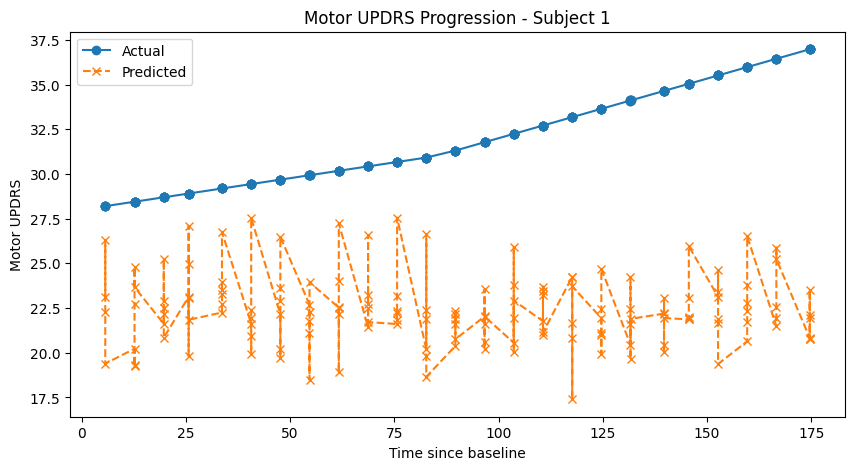

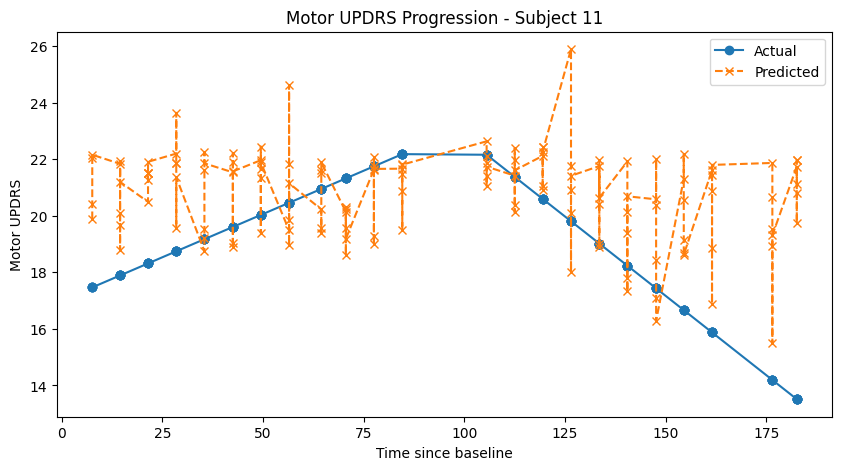

In [13]:
patient_plot_progression(df["subject"].unique()[0])
patient_plot_progression(df["subject"].unique()[10])

In [42]:
from scipy.stats import spearmanr

trend_results = []

for subject_id in df["subject"].unique():
    patient = df[df["subject"] == subject_id]

    if patient.shape[0] < 3:
        continue

    actual_corr, _ = spearmanr(
        patient["test_time"],
        patient["motor_updrs"]
    )

    pred_corr, _ = spearmanr(
        patient["test_time"],
        patient["pred_motor_updrs"]
    )

    trend_results.append({
        "subject": subject_id,
        "actual_trend": actual_corr,
        "predicted_trend": pred_corr
    })

trend_df = pd.DataFrame(trend_results)
trend_df.head(20)


,subject,actual_trend,predicted_trend
0,1,0.999531,-0.072225
1,2,0.999605,0.180329
2,3,0.749441,0.172336
3,4,0.999615,0.264839
4,5,0.901758,-0.072756
5,6,0.500125,0.252740
6,7,-0.337742,-0.140771
7,8,0.999529,-0.140953
8,9,0.954237,0.224748
9,10,0.947924,-0.037356


In [15]:
 print(df.columns.tolist())


['subject', 'age', 'sex', 'test_time', 'motor_updrs', 'total_updrs', 'jitter', 'jitter_abs', 'jitter_rap', 'jitter_ppq5', 'jitter_ddp', 'shimmer', 'shimmer_db', 'shimmer_apq3', 'shimmer_apq5', 'shimmer_apq11', 'shimmer_dda', 'nhr', 'hnr', 'rpde', 'dfa', 'ppe', 'motor_updrs_lag1', 'delta_time', 'delta_updrs', 'updrs_rolling_mean_3', 'updrs_rolling_std_3', 'pred_motor_updrs']


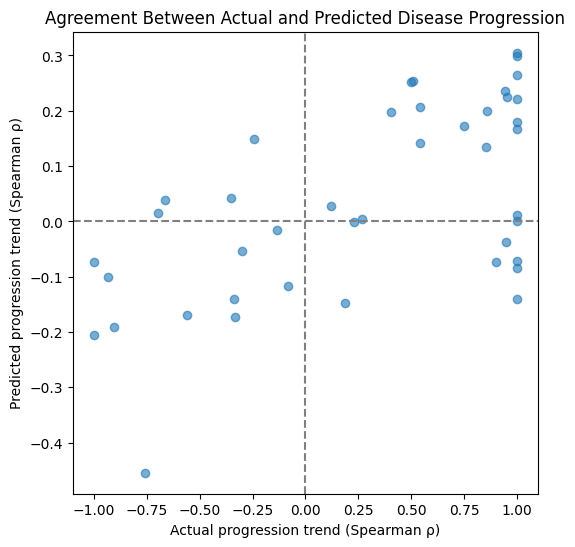

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(
    trend_df["actual_trend"],
    trend_df["predicted_trend"],
    alpha=0.6
)

plt.axhline(0, linestyle="--", color="gray")
plt.axvline(0, linestyle="--", color="gray")

plt.xlabel("Actual progression trend (Spearman ρ)")
plt.ylabel("Predicted progression trend (Spearman ρ)")
plt.title("Agreement Between Actual and Predicted Disease Progression")
plt.show()


In [17]:
subject_errors = (
    df.groupby("subject")
      .apply(lambda x: np.mean(np.abs(
          x["motor_updrs"] - x["pred_motor_updrs"]
      )))
      .reset_index(name="MAE")
)

subject_errors.describe()


C:\Users\Durosimi\AppData\Local\Temp\ipykernel_21872\1387438829.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.mean(np.abs(


,subject,MAE
count,42.000000,42.000000
mean,21.500000,5.509625
std,12.267844,2.758655
min,1.000000,1.365908
25%,11.250000,3.126172
50%,21.500000,5.073941
75%,31.750000,6.869207
max,42.000000,13.169465


In [18]:
from scipy.stats import spearmanr

overall_corr, _ = spearmanr(
    trend_df["actual_trend"],
    trend_df["predicted_trend"]
)

overall_corr


0.5457418361559031

In [19]:
trend_df["actual_direction"] = trend_df["actual_trend"] > 0
trend_df["predicted_direction"] = trend_df["predicted_trend"] > 0

direction_accuracy = (
    trend_df["actual_direction"] == trend_df["predicted_direction"]
).mean()

direction_accuracy


0.7380952380952381

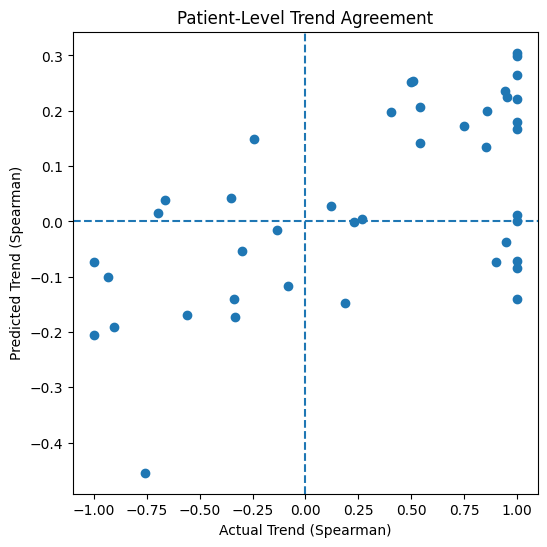

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(
    trend_df["actual_trend"],
    trend_df["predicted_trend"]
)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("Actual Trend (Spearman)")
plt.ylabel("Predicted Trend (Spearman)")
plt.title("Patient-Level Trend Agreement")
plt.show()
